# **SpaceX Falcon 9 First Stage Landing Analytics**

---

## **A. Project Background:**  
---
SpaceX advertises Falcon 9 rocket launches on its website with a cost of \\$62 million; other providers cost upwards of \\$165 million each, much of the savings is because SpaceX can reuse the first stage. Therefore, if we can determine if the first stage will land, we can determine the cost of a launch.

Assuming we would like learn about SpaceX Falcon 9 and determine the price of each launch, we will start by gathering information about SpaceX Falcon 9 Launch and then determine SpaceX first stage booster reusability after launch.
In this project, instead of using rocket science to predict whether SpaceX first stage will land successfully, we will try simple machine learning approach and make use of public information.

**Problem Statement:**
- What features or variables have relationship and able to determine whether first stage will land successfully?
- Which machine learning model performs the best to predict whether first stage will land successfully?
- How are the models performance evaluation on unseen blind test data?

## Import Libraries

In [150]:
import pandas as pd
import requests
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, MousePosition
from folium.features import DivIcon
import wget
import joblib
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, FixedThresholdClassifier, TunedThresholdClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## B. Data Understanding
---

### 0. Aux Functions

In [3]:
# Takes the dataset and uses the rocket column to call the API and append the data to the list
def getBoosterVersion(data):
    for x in data['rocket']:
       if x:
        response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
        BoosterVersion.append(response['name'])

# Takes the dataset and uses the launchpad column to call the API and append the data to the list
def getLaunchSite(data):
    for x in data['launchpad']:
       if x:
         response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
         Longitude.append(response['longitude'])
         Latitude.append(response['latitude'])
         LaunchSite.append(response['name'])

# Takes the dataset and uses the payloads column to call the API and append the data to the lists
def getPayloadData(data):
    for load in data['payloads']:
       if load:
        response = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
        PayloadMass.append(response['mass_kg'])
        Orbit.append(response['orbit'])

# Takes the dataset and uses the cores column to call the API and append the data to the lists
def getCoreData(data):
    for core in data['cores']:
            if core['core'] != None:
                response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
                Block.append(response['block'])
                ReusedCount.append(response['reuse_count'])
                Serial.append(response['serial'])
            else:
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
            Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
            Flights.append(core['flight'])
            GridFins.append(core['gridfins'])
            Reused.append(core['reused'])
            Legs.append(core['legs'])
            LandingPad.append(core['landpad'])

### 1. Data Collection

In [23]:
static_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'
response = requests.get(static_url)

In [24]:
response.status_code

200

STATUS 200: OK

In [25]:
data = pd.json_normalize(response.json())
data.head()

,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,...,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],...,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-fa...,https://en.wikipedia.org/wiki/DemoSat,NaN
1,NaN,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Successful first stage burn and transition to ...,[],[],...,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-roc...,https://en.wikipedia.org/wiki/DemoSat,NaN
2,NaN,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision betwe...,[],[],...,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1...,https://en.wikipedia.org/wiki/Trailblazer_(sat...,NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,Ratsat was carried to orbit on the first succe...,[],[],...,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=dLQ2tZEH6G0,dLQ2tZEH6G0,https://en.wikipedia.org/wiki/Ratsat,https://en.wikipedia.org/wiki/Ratsat,NaN
4,NaN,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,True,NaN,[],[],...,NaN,NaN,[],[],http://www.spacex.com/press/2012/12/19/spacexs...,https://www.youtube.com/watch?v=yTaIDooc8Og,yTaIDooc8Og,http://www.spacex.com/news/2013/02/12/falcon-1...,https://en.wikipedia.org/wiki/RazakSAT,NaN


In [26]:
# Lets take a subset of our dataframe keeping only the features we want and the flight number, and date_utc.
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# We will remove rows with multiple cores because those are falcon rockets with 2 extra rocket boosters and rows that have multiple payloads in a single rocket.
data = data[data['cores'].map(len)==1]
data = data[data['payloads'].map(len)==1]

# Since payloads and cores are lists of size 1 we will also extract the single value in the list and replace the feature.
data['cores'] = data['cores'].map(lambda x : x[0])
data['payloads'] = data['payloads'].map(lambda x : x[0])

# We also want to convert the date_utc to a datetime datatype and then extracting the date leaving the time
data['date'] = pd.to_datetime(data['date_utc']).dt.date

# Using the date we will restrict the dates of the launches
data = data[data['date'] <= datetime.date(2020, 11, 13)]

* From the <code>rocket</code> we would like to learn the booster name

* From the <code>payload</code> we would like to learn the mass of the payload and the orbit that it is going to

* From the <code>launchpad</code> we would like to know the name of the launch site being used, the longitude, and the latitude.

* From <code>cores</code> we would like to learn the outcome of the landing, the type of the landing, number of flights with that core, whether gridfins were used, whether the core is reused, whether legs were used, the landing pad used, the block of the core which is a number used to seperate version of cores, the number of times this specific core has been reused, and the serial of the core.

In [ ]:
# Call function to get each feature request
getBoosterVersion(data)
getLaunchSite(data)
getPayloadData(data)
getCoreData(data)

Finally lets construct our dataset using the data we have obtained. We we combine the columns into a dictionary.


In [ ]:
launch_dict = {'FlightNumber': list(data['flight_number']),
'Date': list(data['date']),
'BoosterVersion':BoosterVersion,
'PayloadMass':PayloadMass,
'Orbit':Orbit,
'LaunchSite':LaunchSite,
'Outcome':Outcome,
'Flights':Flights,
'GridFins':GridFins,
'Reused':Reused,
'Legs':Legs,
'LandingPad':LandingPad,
'Block':Block,
'ReusedCount':ReusedCount,
'Serial':Serial,
'Longitude': Longitude,
'Latitude': Latitude}

data = pd.DataFrame(launch_dict)

Finally we will remove the Falcon 1 launches keeping only the Falcon 9 launches. Filter the data dataframe using the <code>BoosterVersion</code> column to only keep the Falcon 9 launches. Save the filtered data to a new dataframe called <code>data_falcon9</code>. 

Recall that we have removed some values we should reset the FlgihtNumber column

In [ ]:
# Filter for Falcon 9 only
data_falcon9 = df[df['BoosterVersion'] != 'Falcon 1'].copy()

# Reset FlightNumber to run continuously from 1 to 90
data_falcon9['FlightNumber'] = list(range(1, data_falcon9.shape[0] + 1))

In [ ]:
data_falcon9.isnull().sum()

Before we can continue we must deal with these missing values. The <code>LandingPad</code> column will retain None values to represent when landing pads were not used.


In [ ]:
# Calculate the mean value of PayloadMass column
mean_payload = data_falcon9['PayloadMass'].mean()

# Replace the np.nan values with its mean value
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].fillna(mean_payload)

data_falcon9.to_csv('falcon9_data_collected.csv', index=False)

The data from these requests will be stored in lists and will be used to create a new dataframe along with webscraped Falcon 9 Launches records from Wikipedia.

To ensure the dataset needed is consistent, the final dataset collected is provided below \
[https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv)

### 2. Data Wrangling

In [42]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv"
df = pd.read_csv(url)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     str    
 2   BoosterVersion  90 non-null     str    
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     str    
 5   LaunchSite      90 non-null     str    
 6   Outcome         90 non-null     str    
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     str    
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     str    
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
dtypes: bool(3), float64(4), int64(3), str(7)
memory 

In [48]:
df.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

The data contains several Space X  launch facilities: <a href='https://en.wikipedia.org/wiki/List_of_Cape_Canaveral_and_Merritt_Island_launch_sites'>Cape Canaveral Space</a> Launch Complex 40  <b>VAFB SLC 4E </b> , Vandenberg Air Force Base Space Launch Complex 4E <b>(SLC-4E)</b>, Kennedy Space Center Launch Complex 39A <b>KSC LC 39A </b>.The location of each Launch Is placed in the column <code>LaunchSite</code>

let's see the number of launches for each site.

In [52]:
df['LaunchSite'].value_counts()

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64



* <b>LEO</b>: Low Earth orbit (LEO)is an Earth-centred orbit with an altitude of 2,000 km (1,200 mi) or less (approximately one-third of the radius of Earth),[1] or with at least 11.25 periods per day (an orbital period of 128 minutes or less) and an eccentricity less than 0.25.[2] Most of the manmade objects in outer space are in LEO <a href='https://en.wikipedia.org/wiki/Low_Earth_orbit'>[1]</a>.

* <b>VLEO</b>: Very Low Earth Orbits (VLEO) can be defined as the orbits with a mean altitude below 450 km. Operating in these orbits can provide a number of benefits to Earth observation spacecraft as the spacecraft operates closer to the observation<a href='https://www.researchgate.net/publication/271499606_Very_Low_Earth_Orbit_mission_concepts_for_Earth_Observation_Benefits_and_challenges'>[2]</a>.


* <b>GTO</b>(Geostationary Transfer Orbit): A geostationary transfer orbit is an elliptical Earth orbit used to transfer satellites from low Earth orbit (LEO) to geostationary orbit (GEO). In a GTO, the perigee (closest point to Earth) is much lower than GEO altitude, while the apogee (farthest point) reaches approximately 22,236 miles (35,786 kilometers) above Earth’s equator — the altitude of a geostationary orbit. Satellites in GTO use onboard propulsion to circularize their orbit at GEO altitude, where they can provide services such as weather monitoring, communications, and surveillance. <a  href="https://www.space.com/29222-geosynchronous-orbit.html" >[3] </a>.


* <b>SSO (or SO)</b>: It is a Sun-synchronous orbit  also called a heliosynchronous orbit is a nearly polar orbit around a planet, in which the satellite passes over any given point of the planet's surface at the same local mean solar time <a href="https://en.wikipedia.org/wiki/Sun-synchronous_orbit">[4] <a>.
    
    
    
* <b>ES-L1 </b>:At the Lagrange points the gravitational forces of the two large bodies cancel out in such a way that a small object placed in orbit there is in equilibrium relative to the center of mass of the large bodies. L1 is one such point between the sun and the earth <a href="https://en.wikipedia.org/wiki/Lagrange_point#L1_point">[5]</a> .
    
    
* <b>HEO</b> A highly elliptical orbit, is an elliptic orbit with high eccentricity, usually referring to one around Earth <a href="https://en.wikipedia.org/wiki/Highly_elliptical_orbit">[6]</a>.


* <b> ISS </b> A modular space station (habitable artificial satellite) in low Earth orbit. It is a multinational collaborative project between five participating space agencies: NASA (United States), Roscosmos (Russia), JAXA (Japan), ESA (Europe), and CSA (Canada)<a href="https://en.wikipedia.org/wiki/International_Space_Station"> [7] </a>


* <b> MEO </b> Geocentric orbits ranging in altitude from 2,000 km (1,200 mi) to just below geosynchronous orbit at 35,786 kilometers (22,236 mi). Also known as an intermediate circular orbit. These are "most commonly at 20,200 kilometers (12,600 mi), or 20,650 kilometers (12,830 mi), with an orbital period of 12 hours <a href="https://en.wikipedia.org/wiki/List_of_orbits"> [8] </a>


* <b> HEO </b> Geocentric orbits above the altitude of geosynchronous orbit (35,786 km or 22,236 mi) <a href="https://en.wikipedia.org/wiki/List_of_orbits"> [9] </a>


* <b> GEO </b> It is a circular geosynchronous orbit 35,786 kilometres (22,236 miles) above Earth's equator and following the direction of Earth's rotation <a href="https://en.wikipedia.org/wiki/Geostationary_orbit"> [10] </a>


* <b> PO </b> It is one type of satellites in which a satellite passes above or nearly above both poles of the body being orbited (usually a planet such as the Earth <a href="https://en.wikipedia.org/wiki/Polar_orbit"> [11] </a>

some are shown in the following plot:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/Orbits.png)


In [54]:
df['Orbit'].value_counts()

Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64

In [58]:
landing_outcomes = df['Outcome'].value_counts()
landing_outcomes

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64

<code>True Ocean</code> means the mission outcome was successfully  landed to a specific region of the ocean while <code>False Ocean</code> means the mission outcome was unsuccessfully landed to a specific region of the ocean. <code>True RTLS</code> means the mission outcome was successfully  landed to a ground pad <code>False RTLS</code> means the mission outcome was unsuccessfully landed to a ground pad.<code>True ASDS</code> means the mission outcome was successfully  landed to a drone ship <code>False ASDS</code> means the mission outcome was unsuccessfully landed to a drone ship. <code>None ASDS</code> and <code>None None</code> these represent a failure to land.


In [62]:
bad_outcomes = {'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}

This variable will represent the classification variable that represents the outcome of each launch. If the value is zero, the  first stage did not land successfully; one means  the first stage landed Successfully 


In [72]:
df['Class'] = [0 if outcome in bad_outcomes else 1 for outcome in df['Outcome']]
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


df.to_csv('falcon9_dataset_wrangled.csv', index=False)

To ensure the dataset needed is consistent, the final dataset collected is provided below

[https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv)

### 3. EDA

In [4]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


#### Flight Number and Payload Mass Relationship

First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch.

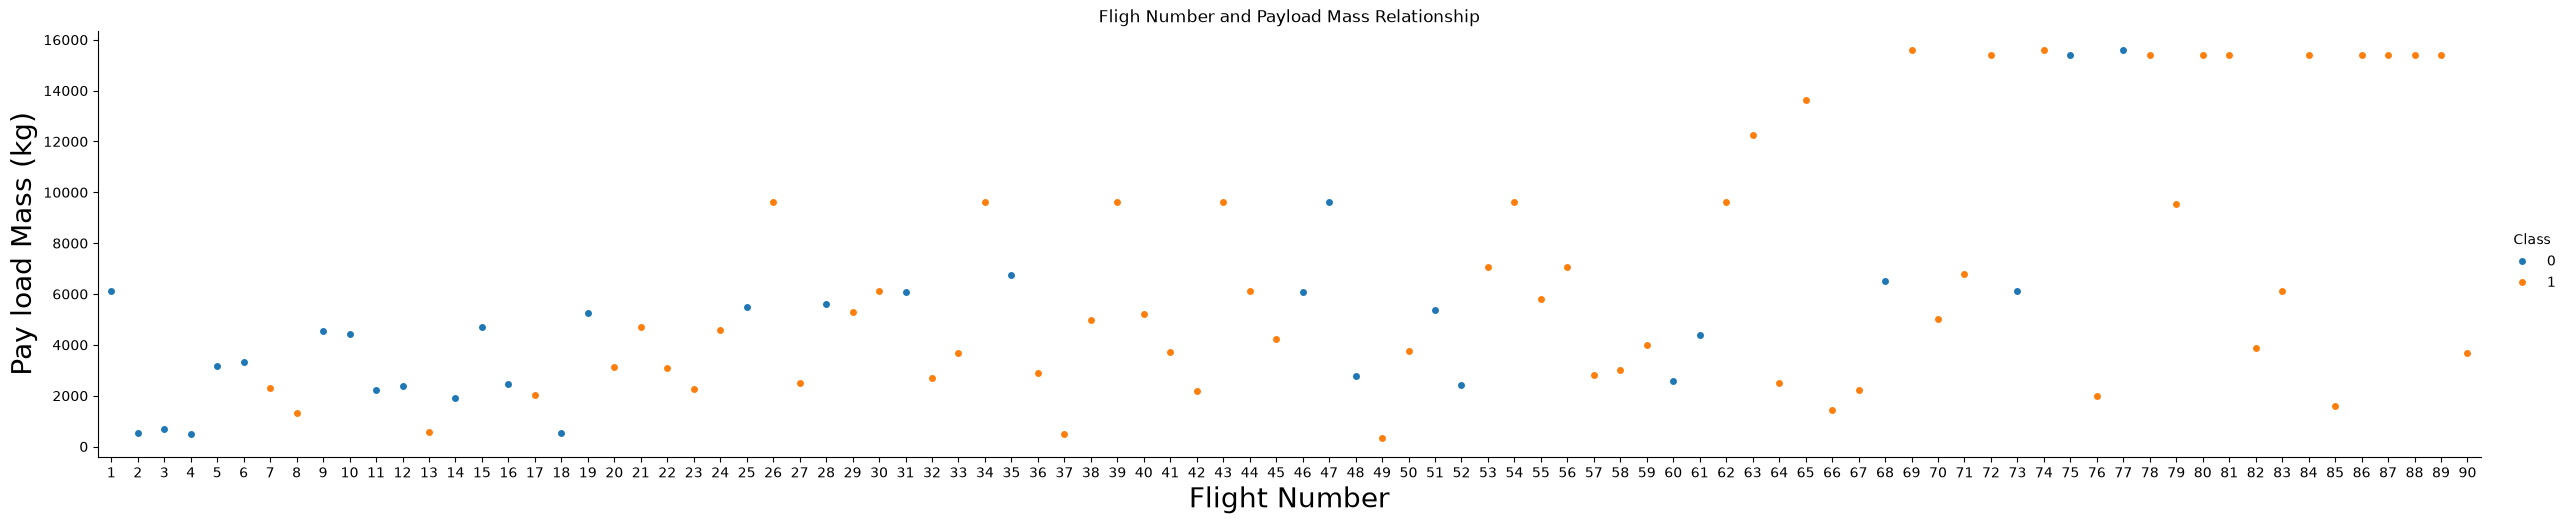

In [8]:
sns.catplot(data=df, x='FlightNumber', y='PayloadMass', hue='Class', aspect=5)
plt.title("Fligh Number and Payload Mass Relationship")
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay load Mass (kg)", fontsize=20)
plt.show()

- As the flight number increases, the first stage is more likely to land successfully.
- The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.

#### Flight Number and Launch Site Relationship

Next, use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


<Figure size 1000x400 with 0 Axes>

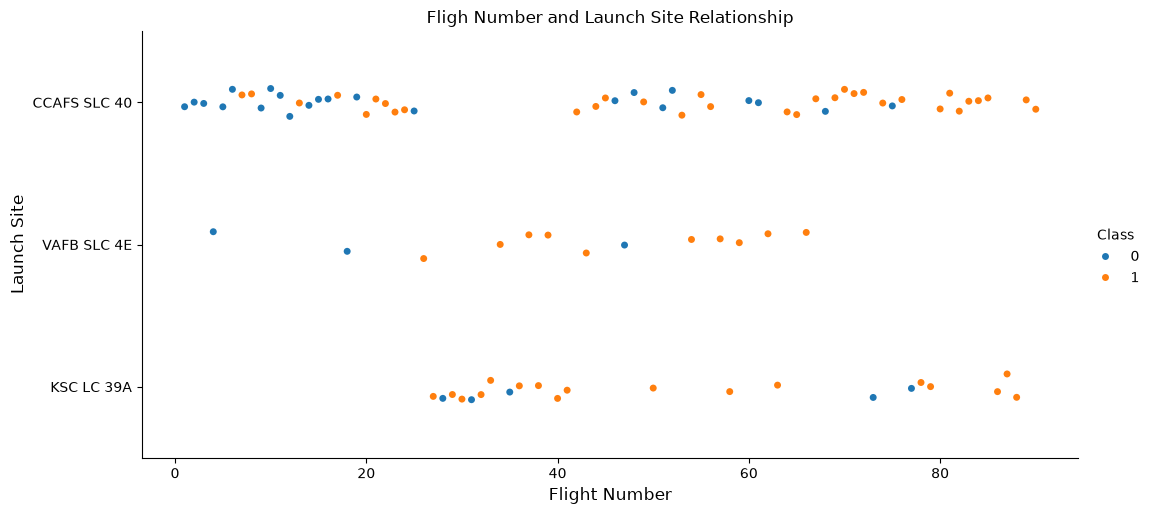

In [56]:
plt.figure(figsize=(10, 4))
sns.catplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class', aspect=2.2)
plt.title("Fligh Number and Launch Site Relationship")
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.show()

In [10]:
pd.crosstab(df['LaunchSite'], df['Class'], normalize='index').style.format('{:.1%}')

Class,0,1
LaunchSite,,
CCAFS SLC 40,40.0%,60.0%
KSC LC 39A,22.7%,77.3%
VAFB SLC 4E,23.1%,76.9%


- As flight number increases, the first stage remains more likely to land successfully
- It seems the majority of first stage failed landing is on site CCAFS SLC-40, with 40% failures. In comparison, the other two sites only accounts roughly 20% failures that might indicates more mature project launch.

#### Launch Site and Payload Mass Relationship

Next, we also want to observe if there is any relationship between launch sites and their payload mass.


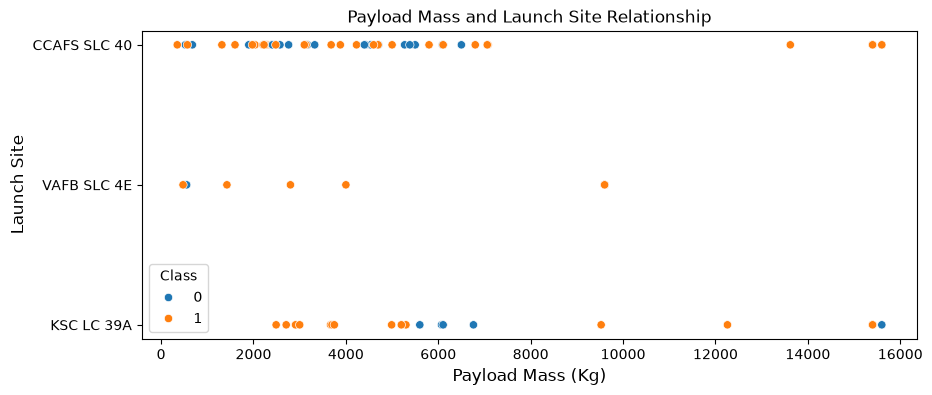

In [11]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class')
plt.title("Payload Mass and Launch Site Relationship")
plt.xlabel("Payload Mass (Kg)", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.show()

- There are no rockets launched for heavy payload mass > 10000 Kg in VAFB-SLC launchsite.

#### Orbit and Outcomes Relationship

Next, we want to visually check if there are any relationship between success rate and orbit type.


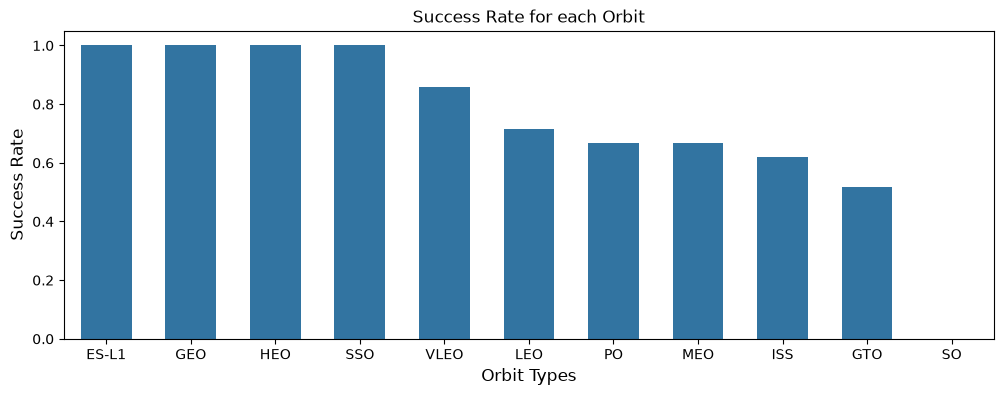

In [12]:
df_orbitSucess = df.groupby('Orbit', as_index=False)['Class'].mean()
df_orbitSucess = df_orbitSucess.sort_values('Class', ascending=False)

plt.figure(figsize=(12, 4))
sns.barplot(data=df_orbitSucess, x='Orbit', y='Class', width=0.6)
plt.title("Success Rate for each Orbit")
plt.xlabel("Orbit Types", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.show()

- ES-L1, GEO, HEO, SSO orbit have 100% success rate
- VLEO, LEO, PO, MEO, ISS orbit have success rate higher than 60%
- SO orbit has 0% success rate

#### Orbit and Flight Number Relationship

Next, for each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


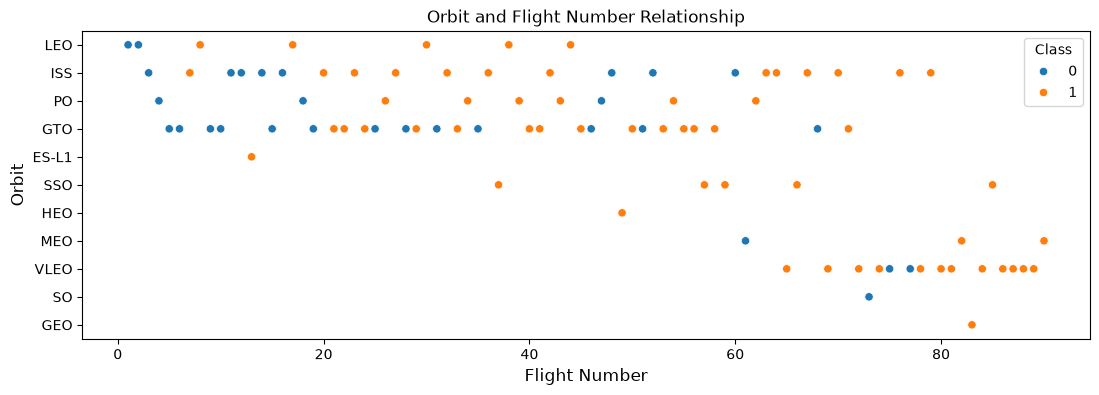

In [13]:
plt.figure(figsize=(13, 4))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class')
plt.title("Orbit and Flight Number Relationship")
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Orbit", fontsize=12)
plt.show()

- We can see that in the LEO orbit the Success appears related to the number of flights
- On the other hand, there seems to be no relationship between flight number when in GTO orbit.


#### Orbit and Payload Mass Relationship

Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


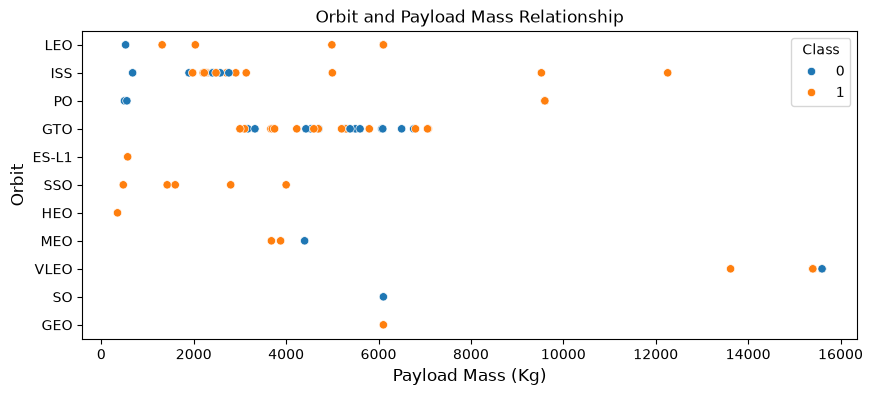

In [14]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class')
plt.title("Orbit and Payload Mass Relationship")
plt.xlabel("Payload Mass (Kg)", fontsize=12)
plt.ylabel("Orbit", fontsize=12)
plt.show()

- With heavy payloads the successful landing or positive landing rate are more for Polar, LEO and ISS.   

- However for GTO we cannot distinguish this well as both positive landing rate and negative landing (unsuccessful mission) are both there here.

#### Yearly Success Outcomes Rate Trend

Next, we want to visualize average launch success rate yearly trend

In [15]:
df_yearly = df[['Date', 'Class']].copy()
df_yearly['Year'] = df_yearly['Date'].dt.year
df_yearlySucess = df_yearly.groupby('Year', as_index=False)['Class'].mean()

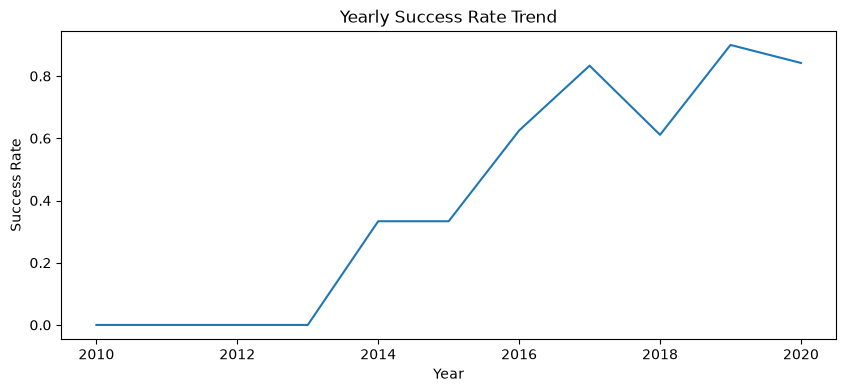

In [16]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_yearlySucess, x='Year', y='Class')
plt.title('Yearly Success Rate Trend')
plt.ylabel('Success Rate')
plt.show()

- We can observe that the success rate since 2013 kept increasing till 2017, whereas it was stable in 2014 and then after 2015 it started increasing.


### 4. Proximities Analysis (Additional Lookup)

#### Visualize Launch Sites Marker

First, let's try to add each site's location on a map using site's latitude and longitude coordinates


In [61]:
df_geo = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
df_geo.head()

,Flight Number,Date,Time (UTC),Booster Version,Launch Site,Payload,Payload Mass (kg),Orbit,Customer,Landing Outcome,class,Lat,Long
0,1,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0.0,LEO,SpaceX,Failure (parachute),0,28.562302,-80.577356
1,2,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel o...",0.0,LEO (ISS),NASA (COTS) NRO,Failure (parachute),0,28.562302,-80.577356
2,3,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2+,525.0,LEO (ISS),NASA (COTS),No attempt,0,28.562302,-80.577356
3,4,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500.0,LEO (ISS),NASA (CRS),No attempt,0,28.562302,-80.577356
4,5,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677.0,LEO (ISS),NASA (CRS),No attempt,0,28.562302,-80.577356


Now, you can take a look at what are the coordinates for each site.


In [66]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
df_geo = df_geo[['Launch Site', 'Lat', 'Long', 'class']]
df_geo_sites = df_geo.groupby(['Launch Site'], as_index=False).first()
df_geo_sites = df_geo_sites[['Launch Site', 'Lat', 'Long']]
df_geo_sites

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


Above coordinates are just plain numbers that can not give you any intuitive insights about where are those launch sites. If you are very good at geography, you can interpret those numbers directly in your mind. If not, that's fine too. Let's visualize those locations by pinning them on a map.


In [75]:
# Initial the map
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=4)

# For each launch site, add a Circle object based on its coordinate (Lat, Long) values. In addition, add Launch site name as a popup label
for _, row in df_geo_sites.iterrows():
    site_coord = [row['Lat'], row['Long']]
    site_name = row['Launch Site']
    
    circle = folium.Circle(
        site_coord, 
        radius=1000, 
        color='#d35400', 
        fill=True
    ).add_child(folium.Popup(site_name))
    
    marker = folium.map.Marker(
        site_coord,
        icon=DivIcon(
            icon_size=(20,20),
            icon_anchor=(0,0),
            html=f'<div style="font-size: 12pt; color: #d35400;"><b>{site_name}</b></div>',
            )
        )
    site_map.add_child(circle)
    site_map.add_child(marker)

site_map

#### Mark The Success/Failed Launch

Next, let's try to enhance the map by adding the launch outcomes for each site, and see which sites have high success rates.
Recall that data frame spacex_df has detailed launch records, and the `class` column indicates if this launch was successful or not


Next, let's create markers for all launch records. 
If a launch was successful `(class=1)`, then we use a green marker and if a launch was failed, we use a red marker `(class=0)`


In [77]:
def assign_marker_color(launch_outcome):
    ''' Function to assign color to launch outcome'''
    if launch_outcome == 1:
        return 'green'
    else:
        return 'red'    

In [82]:
# 1. Initialize the MarkerCluster object
marker_cluster = MarkerCluster()

df_geo['marker_color'] = df_geo['class'].apply(assign_marker_color)

In [83]:
# Add marker_cluster to current site_map
site_map.add_child(marker_cluster)

for index, record in df_geo.iterrows():
    coordinate = [record['Lat'], record['Long']]
    icon = folium.Icon(color='white', icon_color=record['marker_color'])
    
    marker = folium.Marker(
        location=coordinate,
        popup=f"Site: {record['Launch Site']}<br>Outcome: {'Success' if record['class'] == 1 else 'Fail'}",
        icon=icon
    )
    
    marker_cluster.add_child(marker)

site_map

- Relatively High: KSC LC-39A (~77%) & VAFB SLC-4E (~70%) — Dominated by green markers, reflecting flights conducted during mature operational phases (Block 5) and specialized polar trajectories.

- Relatively Low: CCAFS LC-40 (~40%) & CCAFS SLC-40 (~60%) — Dense cluster of red markers, heavily weighed down by SpaceX's early experimental landing trials between 2013 and 2016.

#### Distances of Launch Site to Its Proximities

Next, we need to explore and analyze the proximities of launch sites.


Let's first add a `MousePosition` on the map to get coordinate for a mouse over a point on the map. As such, while you are exploring the map, you can easily find the coordinates of any points of interests (such as railway)


In [84]:
# Add Mouse Position to get the coordinate (Lat, Long) for a mouse over on the map
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)
site_map

Now zoom in to a launch site and explore its proximity to see if you can easily find any railway, highway, coastline, etc. Move your mouse to these points and mark down their coordinates (shown on the top-left) in order to the distance to the launch site.


You can calculate the distance between two points on the map based on their `Lat` and `Long` values using the following method:


In [85]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

In [87]:
# Launch site coordinate (CCAFS SLC-40)
launch_site_coord = [28.562302, -80.577356]

# Coordinates for nearby landmarks around Cape Canaveral
proximities = {
    "Coastline": [28.56367, -80.56763],
    "Highway (Samuel C Phillips Pkwy)": [28.56285, -80.5707],
    "Railroad (NASA Railroad)": [28.57205, -80.58527],
    "City (Titusville)": [28.6120, -80.8076]
}

In [88]:
for name, target_coord in proximities.items():
    dist = calculate_distance(
        launch_site_coord[0], launch_site_coord[1],
        target_coord[0], target_coord[1]
    )
    print(f"Distance to {name}: {dist:.2f} km")

    distance_marker = folium.Marker(
        target_coord,
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 11pt; color: #d35400; font-weight: bold;">{dist:.2f} KM</div>'
        )
    )
    site_map.add_child(distance_marker)

    line = folium.PolyLine(
        locations=[launch_site_coord, target_coord],
        weight=2,
        color='blue',
        opacity=0.75
    )
    site_map.add_child(line)

site_map

Distance to Coastline: 0.96 km
Distance to Highway (Samuel C Phillips Pkwy): 0.65 km
Distance to Railroad (NASA Railroad): 1.33 km
Distance to City (Titusville): 23.16 km


- Close to Coastlines (< 1–2 km): Essential for flight safety—rockets launch out over open ocean so that stage separations or abort debris fall away from populated areas.
- Close to Highways & Railways (1–3 km): Necessary for freight logistics to transport heavy rocket boosters, payload components, and propellant.
- Distant from Cities (> 15–25 km): Maintained as an intentional safety buffer to protect residential populations from acoustic damage, sonic booms, and potential launch hazards.

## C. Data Preparation
---

### 1. Feature Engineering

#### Feature Selection

We already obtained some preliminary insights about how each important variable would affect the success rate, we will select features that will be used in predictive model.

In [6]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0


#### Feature Encoding

For any categorical feature, we will apply one-hot encoding and assign the value to the variable <code>features_one_hot</code>.


features_one_hot = pd.get_dummies(
    features, 
    columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'], 
    dtype=float
)

Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


features_one_hot = features_one_hot.astype('float64')

features_one_hot.to_csv('falcon9_preprocessed.csv', index=False)

Alternatively, we can use OneHotEncoder from <code>sklearn.preprocessing</code> to include in our model pipeline later

In [70]:
cat_cols = ['Orbit', 'LaunchSite', 'LandingPad']
encoder = preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False)

### 2. Preprocessing

In [19]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [44]:
# X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
X = data[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount']]
X.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>, make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [45]:
Y = data['Class'].to_numpy()

#### Data Split

We split the data into training and testing set with <code>test_size=0.2</code> .

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [41]:
Y_test.shape

(18,)

#### Standardization

We standardize the data in <code>X_train</code> then reassign it back to the variable <code>X_train</code> using Standard Scaler.

transform = preprocessing.StandardScaler()
X_train = transform.fit_transform(X_train)
X_test = transform.transform(X_test)

In [71]:
num_cols = list(set(X.columns) - set(cat_cols))
scaler = preprocessing.StandardScaler()

Next, we standardize the data for every <code>Train Set</code>, and since we will tune hyperparameter using <code>GridSearchCV</code> later on, we utilize model pipeline to ensure GridSearch cross validation are properly scaled between each fold.

Note: we don't need to fit test set to ensure no data leakage

## D. Modeling
---

### 1. Model Training

In [ ]:
# def plot_confusion_matrix(y,y_predict):
#     cm = confusion_matrix(y, y_predict)
#     ax= plt.subplot()
#     sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
#     ax.set_xlabel('Predicted labels')
#     ax.set_ylabel('True labels')
#     ax.set_title('Confusion Matrix'); 
#     ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
#     plt.show() 

In [49]:
def plot_confusion_matrix(data_test, data_pred):
    cMatrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(data_test, data_pred))
    cMatrix.plot(cmap='Blues')
    plt.plot()
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks([0, 1], ['fail', 'success'])
    plt.yticks([0, 1], ['fail', 'success'])
    plt.show()

In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, cat_cols),
        ('num', scaler, num_cols)
    ]
)

pipe = Pipeline(steps=[('preprocessor', preprocessor)])

#### LogReg

Next, we create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [73]:
model_name = 'logreg'
parameters ={'C':[0.01,0.1,1],
             'l1_ratio':[0],
             'solver':['lbfgs']}

pipe_lr = clone(pipe)
pipe_lr.steps.append((model_name, LogisticRegression()))
parameters = {f'{model_name}__{k}': v for k, v in parameters.items()}

In [74]:
logreg_cv = GridSearchCV(pipe_lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.01, 0.1, ...], 'logreg__l1_ratio': [0], 'logreg__solver': ['lbfgs']}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [77]:
print("tuned hpyerparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'logreg__C': 0.1, 'logreg__l1_ratio': 0, 'logreg__solver': 'lbfgs'}
accuracy : 0.8339285714285714


In [76]:
lr_test_score = logreg_cv.score(X_test, Y_test)
print("test accuracy:", lr_test_score)

test accuracy: 0.8333333333333334


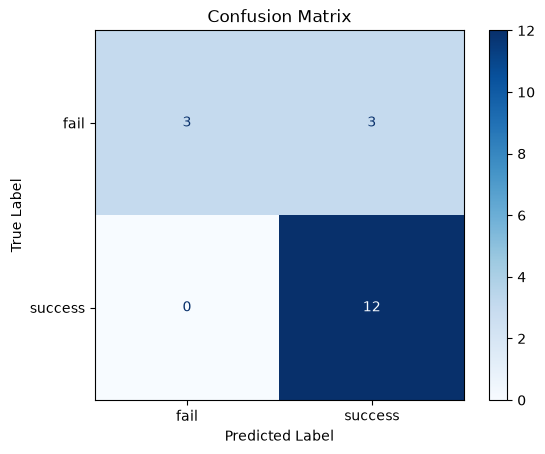

In [78]:
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


#### SVM

Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [128]:
model_name = 'svm'
parameters = {'kernel':('linear', 'rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}

pipe_svm = clone(pipe)
pipe_svm.steps.append((model_name, SVC()))
parameters = {f'{model_name}__{k}': v for k, v in parameters.items()}

In [129]:
svm_cv = GridSearchCV(pipe_svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': array([1.0000...00000000e+03]), 'svm__gamma': array([1.0000...00000000e+03]), 'svm__kernel': ('linear', ...)}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verb

In [130]:
print("tuned hpyerparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'svm__C': np.float64(0.03162277660168379), 'svm__gamma': np.float64(0.001), 'svm__kernel': 'linear'}
accuracy : 0.8339285714285714


In [131]:
svm_test_score = svm_cv.score(X_test, Y_test)
print("test accuracy:", svm_test_score)

test accuracy: 0.8333333333333334


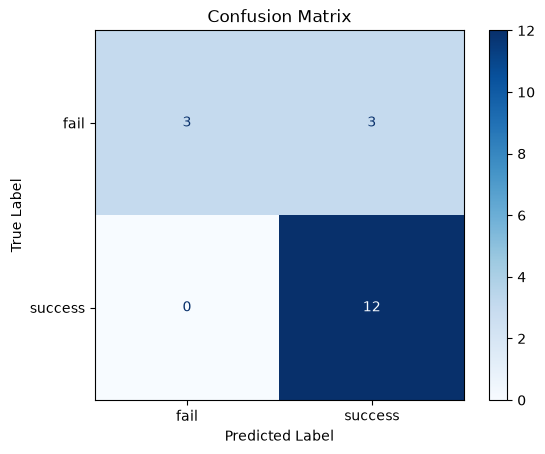

In [132]:
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

SVM model returns exactly same confusion matrix as LogReg did

#### Decision Tree

Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [89]:
model_name = 'tree'
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

pipe_tree = clone(pipe)
pipe_tree.steps.append((model_name, DecisionTreeClassifier()))
parameters = {f'{model_name}__{k}': v for k, v in parameters.items()}

In [90]:
tree_cv = GridSearchCV(pipe_tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'tree__criterion': ['gini', 'entropy'], 'tree__max_depth': [2, 4, ...], 'tree__max_features': ['sqrt'], 'tree__min_samples_leaf': [1, 2, ...], ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for ca

In [91]:
print("tuned hpyerparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'tree__criterion': 'gini', 'tree__max_depth': 6, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 4, 'tree__min_samples_split': 5, 'tree__splitter': 'random'}
accuracy : 0.9017857142857142


In [92]:
tree_test_score = tree_cv.score(X_test, Y_test)
print("test accuracy:", tree_test_score)

test accuracy: 0.8333333333333334


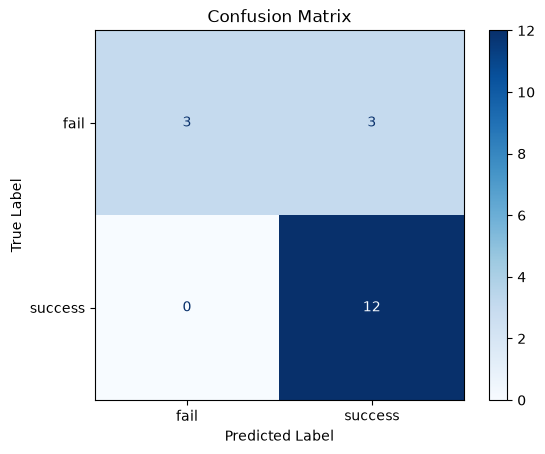

In [93]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

Decision Tree model performs as well as LogReg and SVM.

#### KNN

Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [94]:
model_name = 'knn'
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

pipe_knn = clone(pipe)
pipe_knn.steps.append((model_name, KNeighborsClassifier()))
parameters = {f'{model_name}__{k}': v for k, v in parameters.items()}

In [95]:
knn_cv = GridSearchCV(pipe_knn, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__algorithm': ['auto', 'ball_tree', ...], 'knn__n_neighbors': [1, 2, ...], 'knn__p': [1, 2]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [96]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'knn__algorithm': 'auto', 'knn__n_neighbors': 9, 'knn__p': 1}
accuracy : 0.8357142857142857


In [97]:
knn_test_score = knn_cv.score(X_test, Y_test)
print("test accuracy:", knn_test_score)

test accuracy: 0.8333333333333334


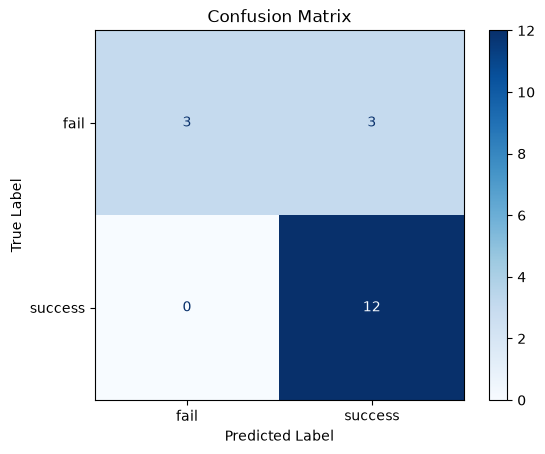

In [98]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

KNN model is similar to the other model.

### 2. Model Selection

ROC - AUC Comparison between each model

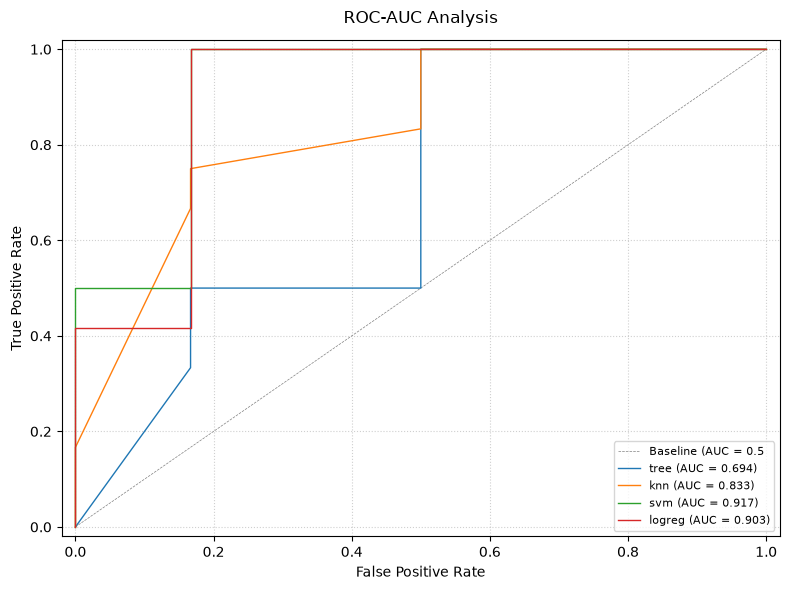

In [195]:
models = {
    'tree': tree_cv,
    'knn': knn_cv,
    'svm': svm_cv,
    'logreg': logreg_cv
}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.5', lw=0.5)

for name, cv_model in models.items():
    best_estimator = cv_model.best_estimator_
    
    # Extract probability scores for the positive class (landing success = 1)
    if hasattr(best_estimator, "predict_proba"):
        y_scores = best_estimator.predict_proba(X_test)[:, 1]
    elif hasattr(best_estimator, "decision_function"):
        y_scores = best_estimator.decision_function(X_test)
    else:
        raise AttributeError(f"{name} does not have predict_proba or decision_function.")

    fpr, tpr, _ = roc_curve(Y_test, y_scores)
    auc_score = roc_auc_score(Y_test, y_scores)
    
    # Plot curve
    plt.plot(fpr, tpr, lw=1, label=f'{name} (AUC = {auc_score:.3f})')

plt.title('ROC-AUC Analysis', pad=12)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Based on overall tuned LogReg, SVM, and KNN model, it shows that all of them perform similarly.

In this case, we want to assume linear decision boundary is enough to capture early phase of launch project pattern. \
Additionally, we need simple model with highly intepretable and fast inference using class probs.

For that reason, we would suggest to choose LogReg model as our classifier to determine whether first stage landing success or fail.


In [139]:
# Using brute force tuning
threshold_tuner = TunedThresholdClassifierCV(
    estimator=logreg_cv.best_estimator_,
    scoring='recall',
    cv=10,
    thresholds=100
)

threshold_tuner.fit(X_train, Y_train)
threshold = threshold_tuner.best_threshold_
print(f"Optimal Threshold: {threshold:.3f}")

Optimal Threshold: 0.122


In [146]:
# Using Youden's J Score similar to Elbow Method
yhat = logreg_cv.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(Y_test, yhat)
threshold = roc_thresholds[np.argmax(tpr - fpr)]

print(f"Optimal Threshold: {threshold:.3f}")

Optimal Threshold: 0.679


We can further adjust the LogReg threshold using domain knowledge, geometric balance on ROC curve, or tuning algorithms, and see the final evaluation.

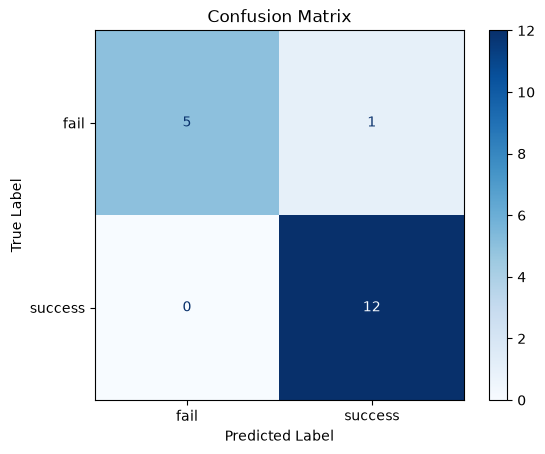

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.92      1.00      0.96        12

    accuracy                           0.94        18
   macro avg       0.96      0.92      0.93        18
weighted avg       0.95      0.94      0.94        18



In [147]:
yhat_optimal = (logreg_cv.predict_proba(X_test)[:, 1] >= threshold).astype(int)
plot_confusion_matrix(Y_test, yhat_optimal)
print(classification_report(Y_test, yhat_optimal, zero_division=0))

Save the model locally

In [151]:
model_selected = FixedThresholdClassifier(
    estimator=logreg_cv.best_estimator_,
    threshold=threshold
)

joblib.dump(model_selected, './model/model_logreg.joblib')

['./model/model_logreg.joblib']

Feature Importance Analysis using magnitude of LogReg coefficient

In [218]:
logreg_coef = logreg_cv.best_estimator_.named_steps['logreg'].coef_[0]
logreg_feat = logreg_cv.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

df_coefs = pd.DataFrame({'Feature': logreg_feat, 'Coefficient': logreg_coef})

base_features = cat_cols + num_cols

base_coefs = []
for base in base_features:
    matches = df_coefs[
        (df_coefs['Feature'] == f"num__{base}") |
        (df_coefs['Feature'].str.startswith(f"cat__{base}_"))
    ]
    if len(matches) > 0:
        rms_score = np.sqrt(np.mean(matches['Coefficient']**2))
        base_coefs.append({'Feature': base, 'RMS_Coef': rms_score, 'n-feat': len(matches)})

df_logreg = pd.DataFrame(base_coefs)
# df_logreg['Importance'] = preprocessing.MinMaxScaler().fit_transform(df_logreg['RMS_Coef'].values.reshape(-1, 1))
df_logreg['Importance'] = df_logreg['RMS_Coef'] / df_logreg['RMS_Coef'].sum()

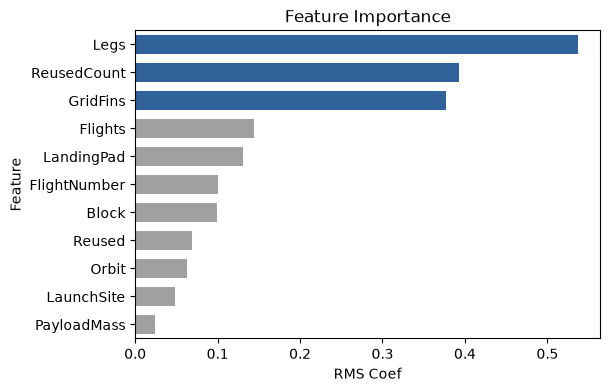

In [225]:
sorted_feat = df_logreg.sort_values(by='Importance', ascending=False)['Feature']
colors = {
    feature: '#1E60AA' if i < 3 else '#A0A0A0' 
    for i, feature in enumerate(sorted_feat)
}

plt.figure(figsize=(6, 4))
sns.barplot(data=df_logreg, y='Feature', x='RMS_Coef', hue='Feature', order=sorted_feat, palette=colors, width=0.7)
plt.title('Feature Importance')
plt.xlabel('RMS Coef')
plt.show()

# Conclusion
---

1. Based on our analysis using LogReg root mean squared coefficients, we can conclude that Legs, ReusedCount, and GridFins are top-3 features for LogReg model to determine first landing outcome. (not neccessarily implying causality)
2. Out of all ML models trained, we decided that Logistic Regression model is the best model to our case, having simple inference using probabilities and highly interpretable, despite the identical accuracy on each model (might be caused by small sample for training).
3. All models trained achieved identical test accuracy of 83.33%, that is 15 out 18 test case are correctly predicted. Moreover, the TP, TN, FP, FN classification report are exactly the same.

The simple machine learning models demonstrate solid predictive generalization using public launch data, reaching the practical limit of accuracy attainable without low-level descent telemetry and real-time metrics.